# Análisis de cohortes & Survival Analysis aplicado a análisis de Churn

El análisis de cohortes es el análisis de comportamiento de un segmento determinado de usuarios que comparten una característica en común en un periodo de tiempo.

El análisis de cohortes funciona como una segmentación de usuarios de los que se tiene en cuenta su comportamiento histórico para detectar patrones o cambios de comportamientos a lo largo del ciclo de vida del usuario. Es especialmente interesante para descubrir tendencias y tomar medidas.

Por ejemplo, una cohorte podría ser todos los usuarios que se han registrado en un día determinado. Sobre este segmento se realizaría un análisis sobre cómo se comportan estos usuarios, qué acciones realizan y en qué se diferencia su comportamiento respecto a otros grupos de usuarios.

Especialmente útil resulta a la hora de analizar retención de usuario

![alt text](http://3.bp.blogspot.com/-TJzEuH70b1E/VUXCxd1yy9I/AAAAAAAAAI4/HQutgYTzsn4/s1600/retention%2BPS%2B%2B3.jpg?auto=webp&quality=85,70"Title")

En el presente notebook mostraremos cómo podemos hacer este tipo de análisis

## 1. Análisis de cohortes

El dataset **gamelaunch** de la librería survminer describe una simulación de datos de eventos para una app de un juego de móvil, recopilando datos durante el primer mes de lanzamiento. Está compuesto por 3 columnas:

- userid: Identificador de usuario único
- eventDate: Fecha en la que recolectamos el evento
- eventName: Tipo de evento recolectado (gameStarted o userCreation)

Un único usuario aparecerá en tantas filas como veces haya generado el evento. Por ejemplo, un usuario que se registre por primera vez y que se meta en la app 4 días habrá generado 5 eventos y por lo tanto se generarán 5 instancias en nuestro dataset (1 de userCreation y 4 de gameStarted, uno por cada día)

In [ ]:
install.packages("cohorts")
install.packages("survminer")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘KMsurv’, ‘km.ci’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘survMisc’, ‘ggtext’




In [ ]:
library(tidyverse)
library(cohorts)
library(dplyr)
library(survival)
library(survminer)

head(gamelaunch)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




userid,eventDate,eventName
<chr>,<dttm>,<chr>
7479a3b347cb2e174ef83afb4211277279f82ce8c6236457f087ad8992d07ffc,2016-05-24,gameStarted
1852e89f7d86b4a0fc29f72bb8c5794d558d61fba1c5acb7cc271bf3ce76e832,2016-05-24,gameStarted
bda71b9de88cd162831d89582480554b7db31bc6b3219c8c92e1ad97aa620942,2016-05-24,gameStarted
29b194585a20e1763b3a92b10eb5af3d593c6767213bd31cebac2a1f4391bc58,2016-05-24,gameStarted
bcb495e6ec9f290f4a44b826098e1e319710dffa9565ae0e5f1066bee2ebdf05,2016-05-24,gameStarted
361e53b758ed3526442f689b8c8104ac8446426d976536f66d8a36ff97df8d88,2016-05-24,gameStarted


In [ ]:
summary(gamelaunch)

    userid            eventDate                    eventName        
 Length:29324       Min.   :2016-04-27 00:00:00   Length:29324      
 Class :character   1st Qu.:2016-05-04 00:00:00   Class :character  
 Mode  :character   Median :2016-05-10 00:00:00   Mode  :character  
                    Mean   :2016-05-11 06:30:26                     
                    3rd Qu.:2016-05-18 00:00:00                     
                    Max.   :2016-05-27 00:00:00                     

In [ ]:
str(gamelaunch)

tibble [29,324 × 3] (S3: tbl_df/tbl/data.frame)
 $ userid   : chr [1:29324] "7479a3b347cb2e174ef83afb4211277279f82ce8c6236457f087ad8992d07ffc" "1852e89f7d86b4a0fc29f72bb8c5794d558d61fba1c5acb7cc271bf3ce76e832" "bda71b9de88cd162831d89582480554b7db31bc6b3219c8c92e1ad97aa620942" "29b194585a20e1763b3a92b10eb5af3d593c6767213bd31cebac2a1f4391bc58" ...
 $ eventDate: POSIXct[1:29324], format: "2016-05-24" "2016-05-24" ...
 $ eventName: chr [1:29324] "gameStarted" "gameStarted" "gameStarted" "gameStarted" ...
 - attr(*, "spec")=
  .. cols(
  ..   userid = col_character(),
  ..   eventDate = col_datetime(format = ""),
  ..   eventName = col_character()
  .. )


### Tabla con cohortes diarios
La librería cohortes permite hacer una pivotación por cohortes para días y para meses. La función cohort_table_day nos manipulará la información creando un dataframe con las siguientes características:

- Columnas: Una columna por cada día que haya en nuestro dataset, representando las fechas
- Filas: Una fila por cada día que haya en nuestro dataset, representando la acquisición de un usuario mediante primera fecha en la que el usuario fue visto en nuestro dataset
- Celdas: El número de usuarios que fueron adquiridos en el cohorte (Fila) que tuvieron actividad en la fecha (columna)

In [ ]:
gamelaunch %>%
       cohort_table_day(id_var = userid, date = eventDate)

cohort,2016-04-27,2016-04-28,2016-04-29,2016-04-30,2016-05-01,2016-05-02,2016-05-03,2016-05-04,2016-05-05,⋯,2016-05-18,2016-05-19,2016-05-20,2016-05-21,2016-05-22,2016-05-23,2016-05-24,2016-05-25,2016-05-26,2016-05-27
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,96,65,55,46,46,45,44,33,34,⋯,23,16,20,13,23,21,17,16,15,16
2,NA,200,117,96,84,82,76,62,72,⋯,33,36,38,32,27,29,32,30,29,25
3,NA,NA,370,207,181,152,138,127,114,⋯,49,53,55,47,47,43,45,46,44,53
4,NA,NA,NA,387,223,177,151,129,122,⋯,69,61,57,62,57,50,48,49,46,47
5,NA,NA,NA,NA,405,222,178,152,130,⋯,59,46,60,62,53,48,42,46,41,40
6,NA,NA,NA,NA,NA,325,183,146,125,⋯,47,43,54,44,53,40,41,39,38,34
7,NA,NA,NA,NA,NA,NA,270,165,129,⋯,55,52,58,50,55,55,42,45,54,46
8,NA,NA,NA,NA,NA,NA,NA,264,142,⋯,39,43,45,35,36,35,31,30,28,34
9,NA,NA,NA,NA,NA,NA,NA,NA,267,⋯,58,57,45,54,46,44,43,38,41,33


Del mismo modo podemos expresarlo como porcentajes:

In [ ]:
gamelaunch %>%
   cohort_table_day(id_var = userid, date = eventDate) %>%
   cohort_table_pct()

cohort,2016-04-27,2016-04-28,2016-04-29,2016-04-30,2016-05-01,2016-05-02,2016-05-03,2016-05-04,2016-05-05,⋯,2016-05-18,2016-05-19,2016-05-20,2016-05-21,2016-05-22,2016-05-23,2016-05-24,2016-05-25,2016-05-26,2016-05-27
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,100,67.7,57.3,47.9,47.9,46.9,45.8,34.4,35.4,⋯,24.0,16.7,20.8,13.5,24.0,21.9,17.7,16.7,15.6,16.7
2,NA,100.0,58.5,48.0,42.0,41.0,38.0,31.0,36.0,⋯,16.5,18.0,19.0,16.0,13.5,14.5,16.0,15.0,14.5,12.5
3,NA,NA,100.0,55.9,48.9,41.1,37.3,34.3,30.8,⋯,13.2,14.3,14.9,12.7,12.7,11.6,12.2,12.4,11.9,14.3
4,NA,NA,NA,100.0,57.6,45.7,39.0,33.3,31.5,⋯,17.8,15.8,14.7,16.0,14.7,12.9,12.4,12.7,11.9,12.1
5,NA,NA,NA,NA,100.0,54.8,44.0,37.5,32.1,⋯,14.6,11.4,14.8,15.3,13.1,11.9,10.4,11.4,10.1,9.9
6,NA,NA,NA,NA,NA,100.0,56.3,44.9,38.5,⋯,14.5,13.2,16.6,13.5,16.3,12.3,12.6,12.0,11.7,10.5
7,NA,NA,NA,NA,NA,NA,100.0,61.1,47.8,⋯,20.4,19.3,21.5,18.5,20.4,20.4,15.6,16.7,20.0,17.0
8,NA,NA,NA,NA,NA,NA,NA,100.0,53.8,⋯,14.8,16.3,17.0,13.3,13.6,13.3,11.7,11.4,10.6,12.9
9,NA,NA,NA,NA,NA,NA,NA,NA,100.0,⋯,21.7,21.3,16.9,20.2,17.2,16.5,16.1,14.2,15.4,12.4


La función shift left nos permite reordenar la tabla de una forma más relevante

In [ ]:
gamelaunch %>%
   cohort_table_day(id_var = userid, date = eventDate) %>%
   cohort_table_pct() %>%
   shift_left()

cohort,t0,t1,t2,t3,t4,t5,t6,t7,t8,⋯,t21,t22,t23,t24,t25,t26,t27,t28,t29,t30
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,100,67.7,57.3,47.9,47.9,46.9,45.8,34.4,35.4,⋯,24.0,16.7,20.8,13.5,24.0,21.9,17.7,16.7,15.6,16.7
2,100,58.5,48.0,42.0,41.0,38.0,31.0,36.0,31.5,⋯,18.0,19.0,16.0,13.5,14.5,16.0,15.0,14.5,12.5,0.0
3,100,55.9,48.9,41.1,37.3,34.3,30.8,26.5,25.7,⋯,14.9,12.7,12.7,11.6,12.2,12.4,11.9,14.3,0.0,0.0
4,100,57.6,45.7,39.0,33.3,31.5,27.6,29.7,29.5,⋯,16.0,14.7,12.9,12.4,12.7,11.9,12.1,0.0,0.0,0.0
5,100,54.8,44.0,37.5,32.1,32.3,31.6,25.4,21.2,⋯,13.1,11.9,10.4,11.4,10.1,9.9,0.0,0.0,0.0,0.0
6,100,56.3,44.9,38.5,36.6,32.3,26.2,22.5,22.2,⋯,12.3,12.6,12.0,11.7,10.5,0.0,0.0,0.0,0.0,0.0
7,100,61.1,47.8,41.9,41.9,37.8,31.5,33.0,27.8,⋯,15.6,16.7,20.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0
8,100,53.8,47.0,34.5,27.7,28.8,30.7,23.9,22.7,⋯,11.4,10.6,12.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,100,57.3,42.7,41.2,37.1,35.2,33.3,27.0,25.5,⋯,15.4,12.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Finalmente, podemos utilizar shift_left_pct para hacer un código más limpio

In [ ]:
cohortTable <- gamelaunch %>%
   cohort_table_day(id_var = userid, date = eventDate) %>%
   shift_left_pct()

cohortTable[cohortTable == 0] <- NA
cohortTable

cohort,t0,t1,t2,t3,t4,t5,t6,t7,t8,⋯,t21,t22,t23,t24,t25,t26,t27,t28,t29,t30
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,100,67.7,57.3,47.9,47.9,46.9,45.8,34.4,35.4,⋯,24.0,16.7,20.8,13.5,24.0,21.9,17.7,16.7,15.6,16.7
2,100,58.5,48.0,42.0,41.0,38.0,31.0,36.0,31.5,⋯,18.0,19.0,16.0,13.5,14.5,16.0,15.0,14.5,12.5,NA
3,100,55.9,48.9,41.1,37.3,34.3,30.8,26.5,25.7,⋯,14.9,12.7,12.7,11.6,12.2,12.4,11.9,14.3,NA,NA
4,100,57.6,45.7,39.0,33.3,31.5,27.6,29.7,29.5,⋯,16.0,14.7,12.9,12.4,12.7,11.9,12.1,NA,NA,NA
5,100,54.8,44.0,37.5,32.1,32.3,31.6,25.4,21.2,⋯,13.1,11.9,10.4,11.4,10.1,9.9,NA,NA,NA,NA
6,100,56.3,44.9,38.5,36.6,32.3,26.2,22.5,22.2,⋯,12.3,12.6,12.0,11.7,10.5,NA,NA,NA,NA,NA
7,100,61.1,47.8,41.9,41.9,37.8,31.5,33.0,27.8,⋯,15.6,16.7,20.0,17.0,NA,NA,NA,NA,NA,NA
8,100,53.8,47.0,34.5,27.7,28.8,30.7,23.9,22.7,⋯,11.4,10.6,12.9,NA,NA,NA,NA,NA,NA,NA
9,100,57.3,42.7,41.2,37.1,35.2,33.3,27.0,25.5,⋯,15.4,12.4,NA,NA,NA,NA,NA,NA,NA,NA


Estos porcentajes nos ayudan a definir el concepto de "Retención de usuario" o lo que es lo mismo, entender cuántos usuarios vuelven a nuestra app pasados N días.

A continuación manipularemos los datos para representar y comparar gráficamente la tabla de cohortes generada

In [ ]:
gamelaunch_long <- gamelaunch %>%
   cohort_table_day(userid, eventDate) %>%
   shift_left_pct() %>% # Hasta aquí todo es igual que lo que hemos visto arriba
   pivot_longer(-cohort) %>% # Pivotamos la columna cohorte para hacer un dataset con 4 columnas
   mutate(time = as.numeric(str_remove(name,"t"))) # Retiramos la t de las instancias de cohorte para dejarlo como valor numérico

head(gamelaunch_long)

cohort,name,value,time
<int>,<chr>,<dbl>,<dbl>
1,t0,100.0,0
1,t1,67.7,1
1,t2,57.3,2
1,t3,47.9,3
1,t4,47.9,4
1,t5,46.9,5


In [ ]:
gamelaunch_long[gamelaunch_long == 0] <- NA # Sustituimos los 0 por Null values
head(gamelaunch_long)

cohort,name,value,time
<int>,<chr>,<dbl>,<dbl>
1,t0,100.0,NA
1,t1,67.7,1
1,t2,57.3,2
1,t3,47.9,3
1,t4,47.9,4
1,t5,46.9,5


Con el dataframe actualizado podemos hacer una representación gráfica:

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


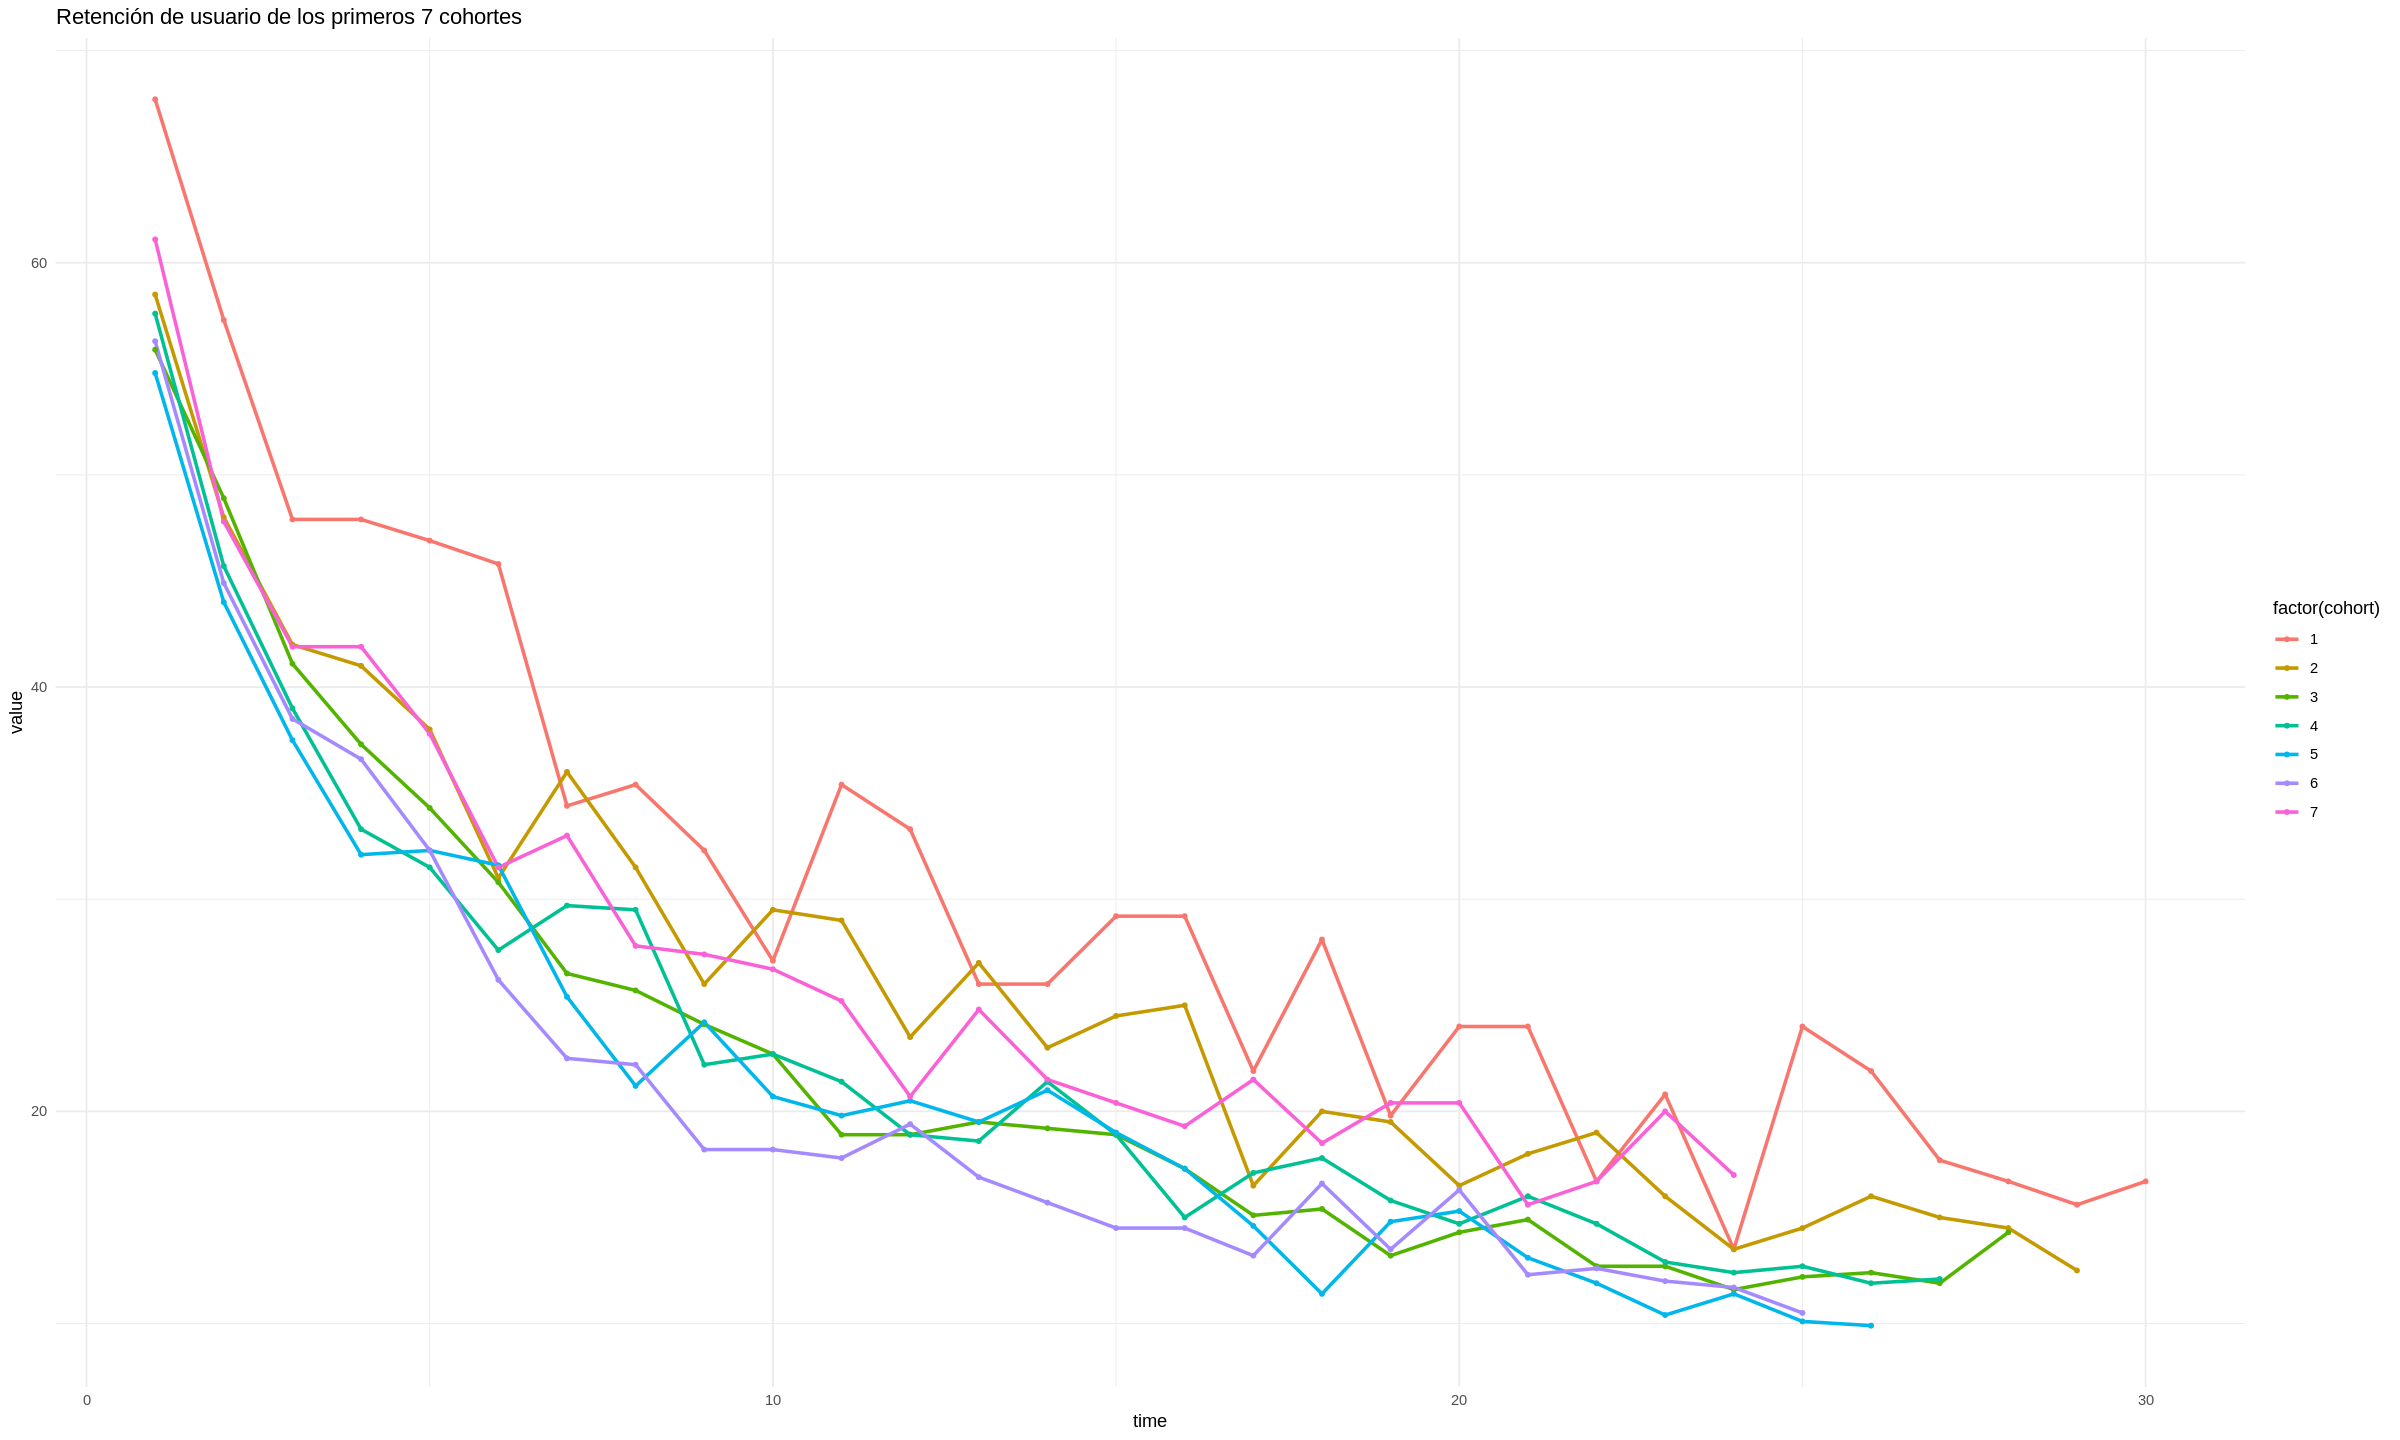

In [ ]:
# Nos permite aumentar el tamaño del plotting
options(repr.plot.width=20, repr.plot.height=12)
# Figura con el plot
gamelaunch_long %>% # Del dataset original...
  filter(cohort <= 7, time > 0, value > 0) %>% # Filtramos únicamente por los primeros 7 cohortes
  ggplot(aes(time, value, colour = factor(cohort), group = cohort)) + # ggplot en el que indicamos los datos y las categorías
  geom_line(size = 1) + # Tipo de gráfica lineal
  geom_point(size = 1) + # Grosor de la gráfica
  ggtitle("Retención de usuario de los primeros 7 cohortes") + # Título del gráfico
  theme_minimal() # Formato de colores

También podemos hacer una mejor visualización de la tabla para todos los cohortes seleccionados

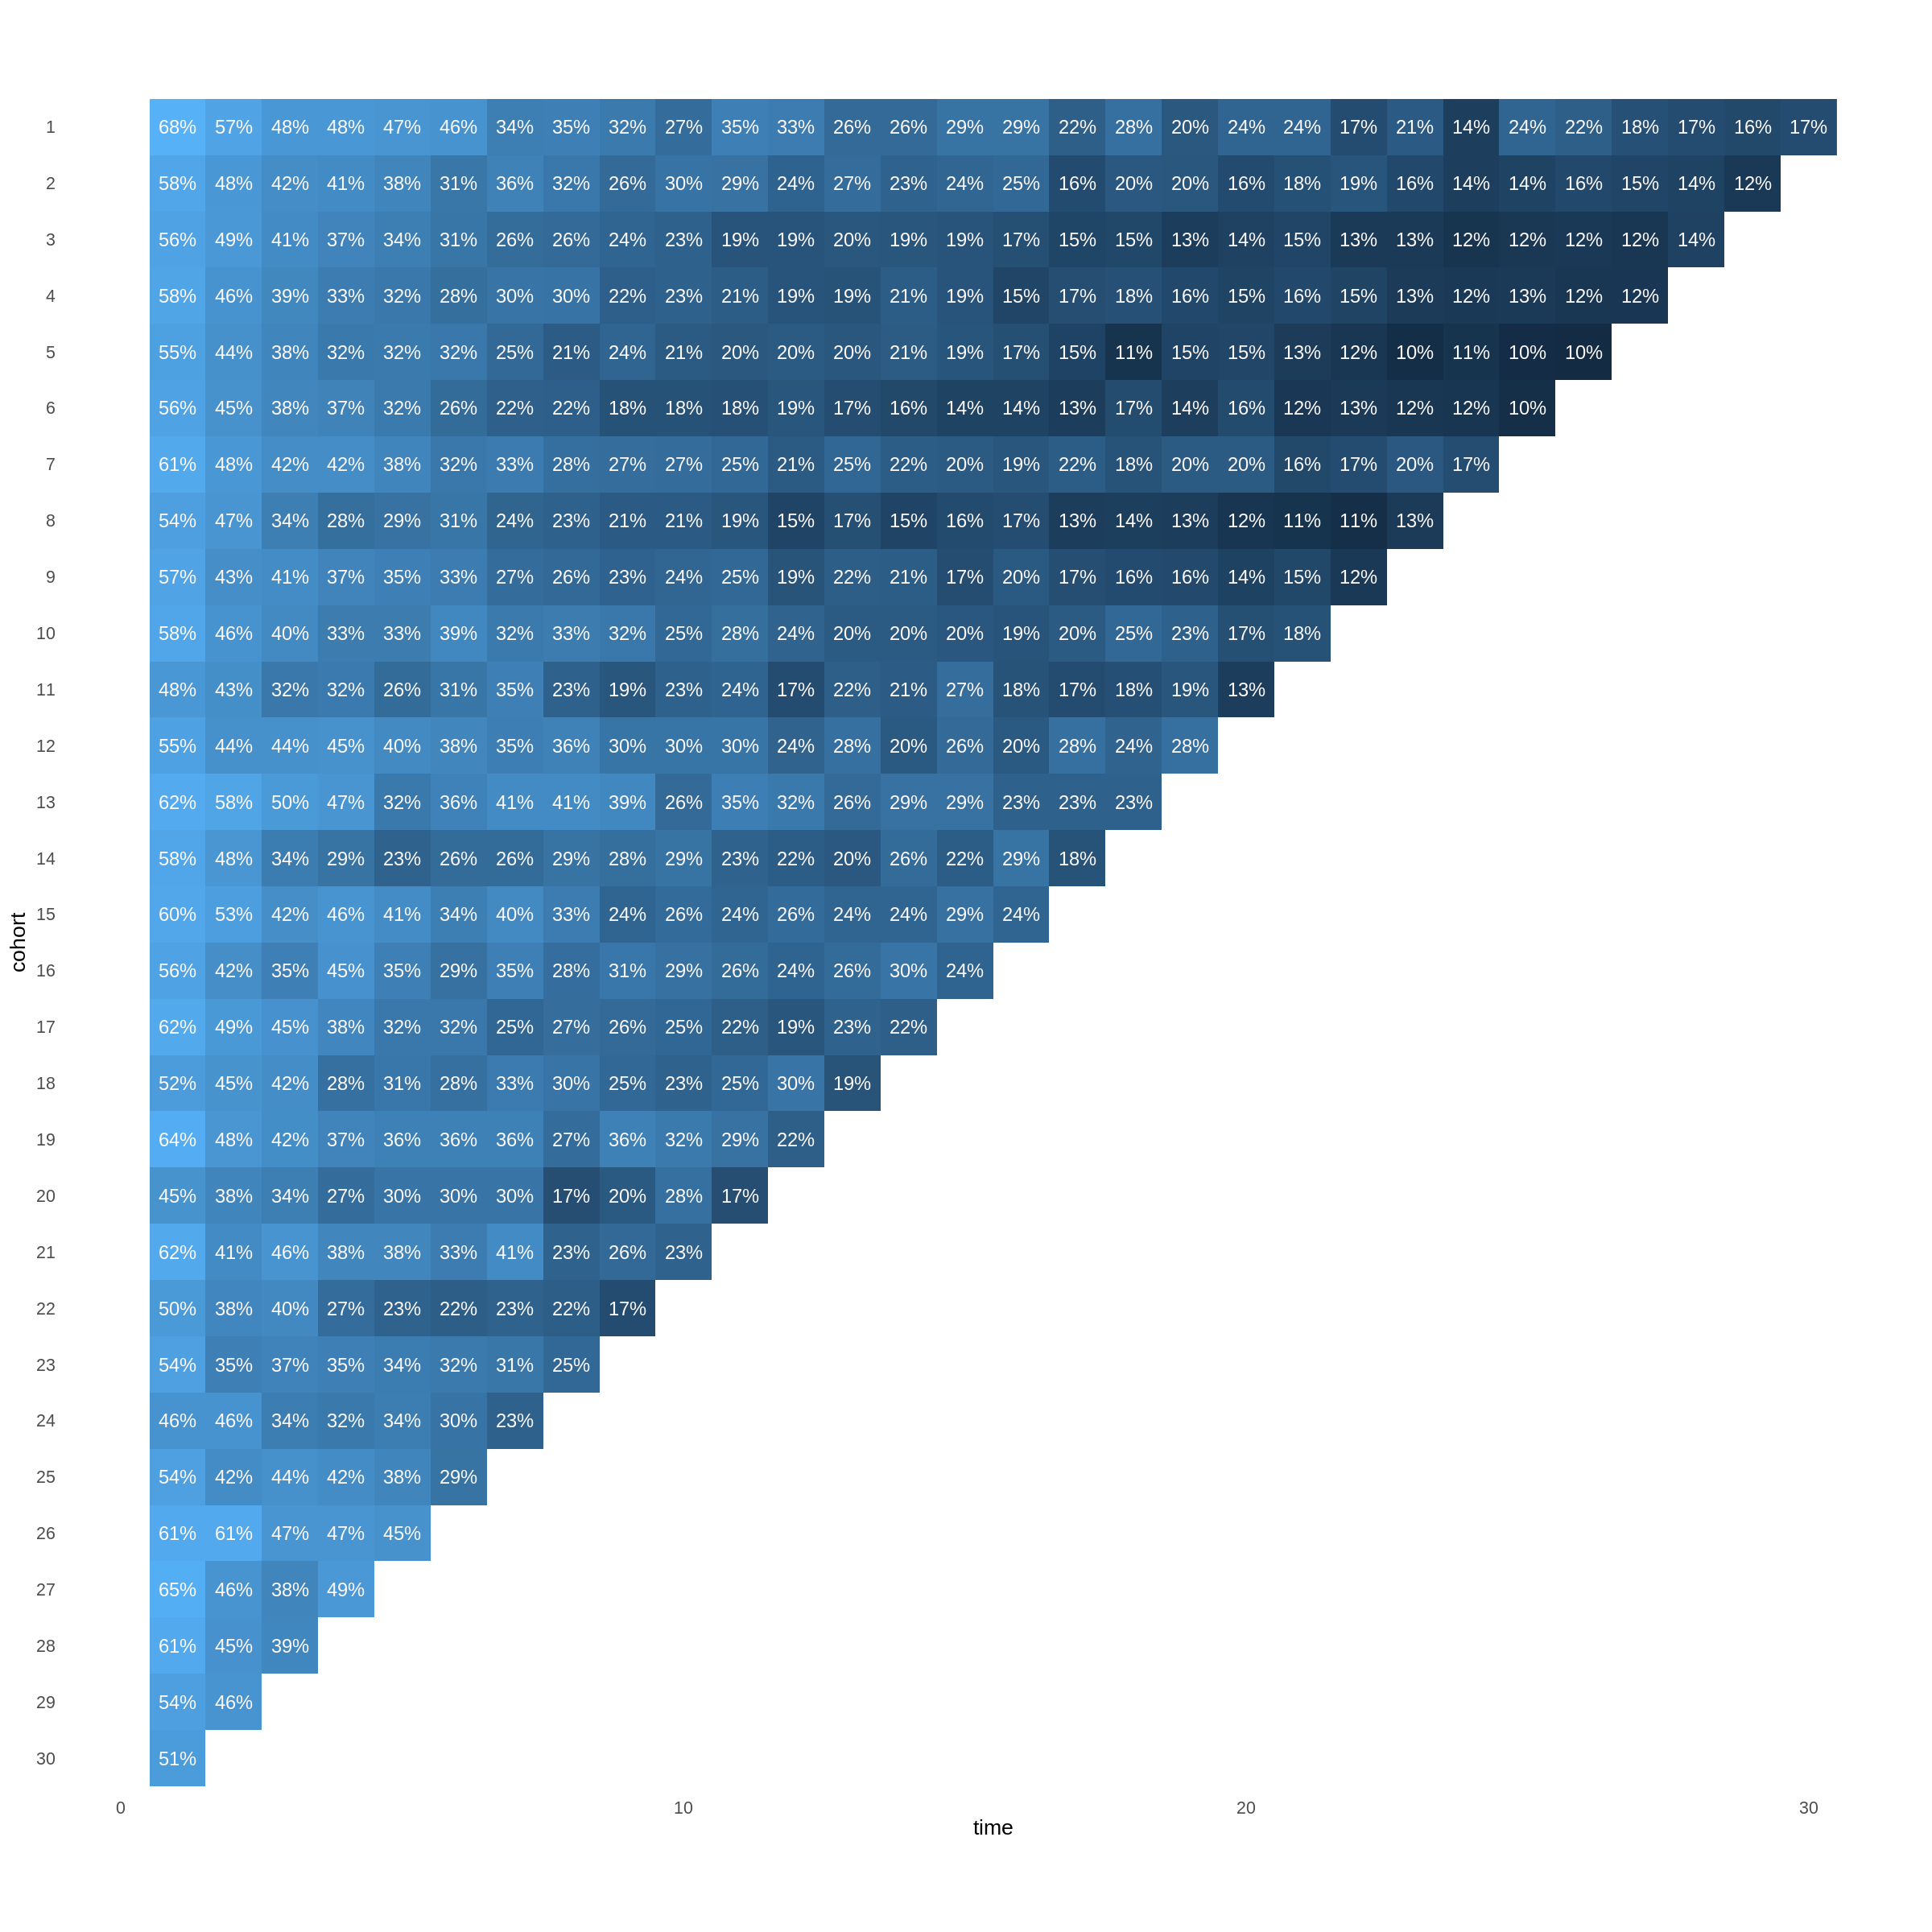

In [ ]:
# Make plots wider
options(repr.plot.width=20, repr.plot.height=20)

gamelaunch_long %>%
   filter(time > 0, value > 0) %>%
   ggplot(aes(time, reorder(cohort, desc(cohort)))) +
   geom_raster(aes(fill = log(value))) +
   coord_equal(ratio = 1) +
   geom_text(aes(label = glue::glue("{round(value,0)}%")),
                 size  = 5,
                 colour = "snow") +
  scale_fill_gradient(guide = "none") +
  theme_minimal(base_size = 16) +
  theme(panel.grid   = element_blank(),
        panel.border = element_blank()) +
  labs(y = "cohort")

## 2. Survival analysis

En este caso vamos a analizar los datos obtenidos desde la óptica del *user churn* mediante el uso de survival analyisis.

In [ ]:
head(data_sales1)
summary(data_sales1)

ERROR: Error: object 'data_sales1' not found


In [ ]:
# Limpiamos el dataset y utilizamos la función abbreviate para reducir el tamaño de los userIds
gamelaunch <- gamelaunch %>%
    mutate(userid=abbreviate(userid))

head(gamelaunch)

userid,eventDate,eventName
<chr>,<dttm>,<chr>
7479,2016-05-24,gameStarted
1852,2016-05-24,gameStarted
b7198,2016-05-24,gameStarted
2919,2016-05-24,gameStarted
b495,2016-05-24,gameStarted
36153,2016-05-24,gameStarted


En este punto vamos a tomar como referencia la siguiente definición de churn: Usuarios que utilizaron la app en algún momento y que dejaron de usarla durante un periodo de al menos 7 días.

Para ello vamos a reducir nuestro dataset a una instancia por usuario y haremos una serie de cálculos para categorizar cada usuario según la definición de churn.

In [ ]:
# Agrupamos el dataset según user id y calculamos la fecha mínima en la que el usuario fue visto (Fecha de cohorte) y la fecha máxima (Fecha última en la que el usuario fue visto)
maxUserDate <- gamelaunch %>%
    group_by(userid) %>%
    summarise(minDate = as.Date(min(eventDate)), maxDate = as.Date(max(eventDate)))

head(maxUserDate)

userid,minDate,maxDate
<chr>,<date>,<date>
0000,2016-05-27,2016-05-27
00090,2016-05-02,2016-05-03
00092,2016-05-05,2016-05-08
0010,2016-05-03,2016-05-16
00160,2016-04-30,2016-05-03
00167,2016-05-03,2016-05-17


In [ ]:
# El churn es un concepto relativo a cada fecha. En este caso hacemos el análisis referenciado a la última fecha disponible
maxUserDate['latestDate'] <- as.Date("2016-05-27")
maxUserDate['latestDateLag7Days'] <- as.Date("2016-05-20") # También incluimos la fecha máxima hasta la que podemos calcular el churn
head(maxUserDate6

)

userid,minDate,maxDate,latestDate,latestDateLag7Days
<chr>,<date>,<date>,<date>,<date>
0000,2016-05-27,2016-05-27,2016-05-27,2016-05-20
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20


In [ ]:
# Calculamos la diferencia de fechas relevantes para nuestro análisis:
maxUserDate['dateDiff'] <- maxUserDate['latestDate'] - maxUserDate['maxDate'] # Nos ayudará a definir usuarios con churn
maxUserDate['userLifetime'] <- maxUserDate['maxDate'] - maxUserDate['minDate'] # Nos ayudará a entender cuándo hacen churn los usuarios
head(maxUserDate, 10)

userid,minDate,maxDate,latestDate,latestDateLag7Days,dateDiff,userLifetime
<chr>,<date>,<date>,<date>,<date>,<drtn>,<drtn>
0000,2016-05-27,2016-05-27,2016-05-27,2016-05-20,0 days,0 days
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20,24 days,1 days
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20,19 days,3 days
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20,11 days,13 days
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20,24 days,3 days
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20,10 days,14 days
0019,2016-05-11,2016-05-11,2016-05-27,2016-05-20,16 days,0 days
0023,2016-05-02,2016-05-02,2016-05-27,2016-05-20,25 days,0 days
00253,2016-05-23,2016-05-27,2016-05-27,2016-05-20,0 days,4 days


In [ ]:
# Cambiamos el formato de los datos a numérico
maxUserDate['dateDiff'] <- lapply(maxUserDate['dateDiff'], function(x) as.numeric(x, units = "days"))
maxUserDate['userLifetime'] <- lapply(maxUserDate['userLifetime'], function(x) as.numeric(x, units = "days"))
head(maxUserDate)

userid,minDate,maxDate,latestDate,latestDateLag7Days,dateDiff,userLifetime
<chr>,<date>,<date>,<date>,<date>,<dbl>,<dbl>
0000,2016-05-27,2016-05-27,2016-05-27,2016-05-20,0,0
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20,24,1
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20,19,3
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20,11,13
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20,24,3
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20,10,14


In [ ]:
# Generamos la condición de churn:
maxUserDate['churned'] <- NA
maxUserDate$churned[maxUserDate['dateDiff'] > 7] <- 1 # SI el usuario ha estado más de 7 días inactivo se le considera churn
maxUserDate$churned[maxUserDate['dateDiff'] <= 6] <- 0 # Si el usuario ha estado inactivo durante 6 dias o menos aún no se le considera
maxUserDate$churned[maxUserDate['minDate'] > maxUserDate['latestDateLag7Days']] <- NA # Los usuarios adquiridos en la última semana no pueden ser categorizados por churn aún
head(maxUserDate,10)

userid,minDate,maxDate,latestDate,latestDateLag7Days,dateDiff,userLifetime,churned
<chr>,<date>,<date>,<date>,<date>,<dbl>,<dbl>,<dbl>
0000,2016-05-27,2016-05-27,2016-05-27,2016-05-20,0,0,NA
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20,24,1,1
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20,19,3,1
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20,11,13,1
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20,24,3,1
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20,10,14,1
0019,2016-05-11,2016-05-11,2016-05-27,2016-05-20,16,0,1
0023,2016-05-02,2016-05-02,2016-05-27,2016-05-20,25,0,1
00253,2016-05-23,2016-05-27,2016-05-27,2016-05-20,0,4,NA


In [ ]:
# En vez de utilizar cohortes diarios haremos un cálculo de cohortes semanales
maxUserDate['cohortWeek'] = lapply(maxUserDate['minDate'], function(x) cut(as.Date(x), "week", start.on.monday = FALSE))
head(maxUserDate)

userid,minDate,maxDate,latestDate,latestDateLag7Days,dateDiff,userLifetime,churned,cohortWeek
<chr>,<date>,<date>,<date>,<date>,<dbl>,<dbl>,<dbl>,<fct>
0000,2016-05-27,2016-05-27,2016-05-27,2016-05-20,0,0,NA,2016-05-22
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20,24,1,1,2016-05-01
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20,19,3,1,2016-05-01
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20,11,13,1,2016-05-01
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20,24,3,1,2016-04-24
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20,10,14,1,2016-05-01


### Cálculo de survival analysis

Una vez hemos generado la categorización de los usuarios estamos listos para hacer el análisis de supervivencia. Para ello utilizaremos la librería survival.

In [ ]:
# Filtramos los datos con churn NA
userData <- maxUserDate %>%
    filter(churned >= 0)
# Generamos el análisis de supervivencia con un tipo de dato surv:
s <- Surv(userData$userLifetime # Indica cuánto tarda un usuario en hacer churn
          , userData$churned) # Categoría de churn
# Descripción de el tipo de dato s
class(s)
head(s, 10)
head(userData, 10)

[1] "Surv"

 [1]  1   3  13   3  14   0   0  28+ 13+ 18+

userid,minDate,maxDate,latestDate,latestDateLag7Days,dateDiff,userLifetime,churned,cohortWeek
<chr>,<date>,<date>,<date>,<date>,<dbl>,<dbl>,<dbl>,<fct>
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20,24,1,1,2016-05-01
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20,19,3,1,2016-05-01
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20,11,13,1,2016-05-01
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20,24,3,1,2016-04-24
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20,10,14,1,2016-05-01
0019,2016-05-11,2016-05-11,2016-05-27,2016-05-20,16,0,1,2016-05-08
0023,2016-05-02,2016-05-02,2016-05-27,2016-05-20,25,0,1,2016-05-01
00255,2016-04-29,2016-05-27,2016-05-27,2016-05-20,0,28,0,2016-04-24
00303,2016-05-13,2016-05-26,2016-05-27,2016-05-20,1,13,0,2016-05-08


In [ ]:
# La función survfit nos hace el análisis de supervivencia
survfit(s~1)

Call: survfit(formula = s ~ 1)

        n events median 0.95LCL 0.95UCL
[1,] 3590   2278      8       7       9

In [ ]:
summary(survfit(s~1))

Call: survfit(formula = s ~ 1)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    0   3590     876    0.756 0.00717        0.742        0.770
    1   2714     271    0.681 0.00778        0.665        0.696
    2   2440     165    0.634 0.00804        0.619        0.650
    3   2270      97    0.607 0.00815        0.592        0.624
    4   2164      95    0.581 0.00824        0.565        0.597
    5   2054      93    0.554 0.00831        0.538        0.571
    6   1940      75    0.533 0.00835        0.517        0.550
    7   1844      76    0.511 0.00837        0.495        0.528
    8   1741      58    0.494 0.00839        0.478        0.511
    9   1648      58    0.477 0.00840        0.460        0.493
   10   1566      61    0.458 0.00840        0.442        0.475
   11   1474      52    0.442 0.00840        0.426        0.459
   12   1393      54    0.425 0.00839        0.409        0.442
   13   1308      42    0.411 0.00838        0.395        0.428
   14   

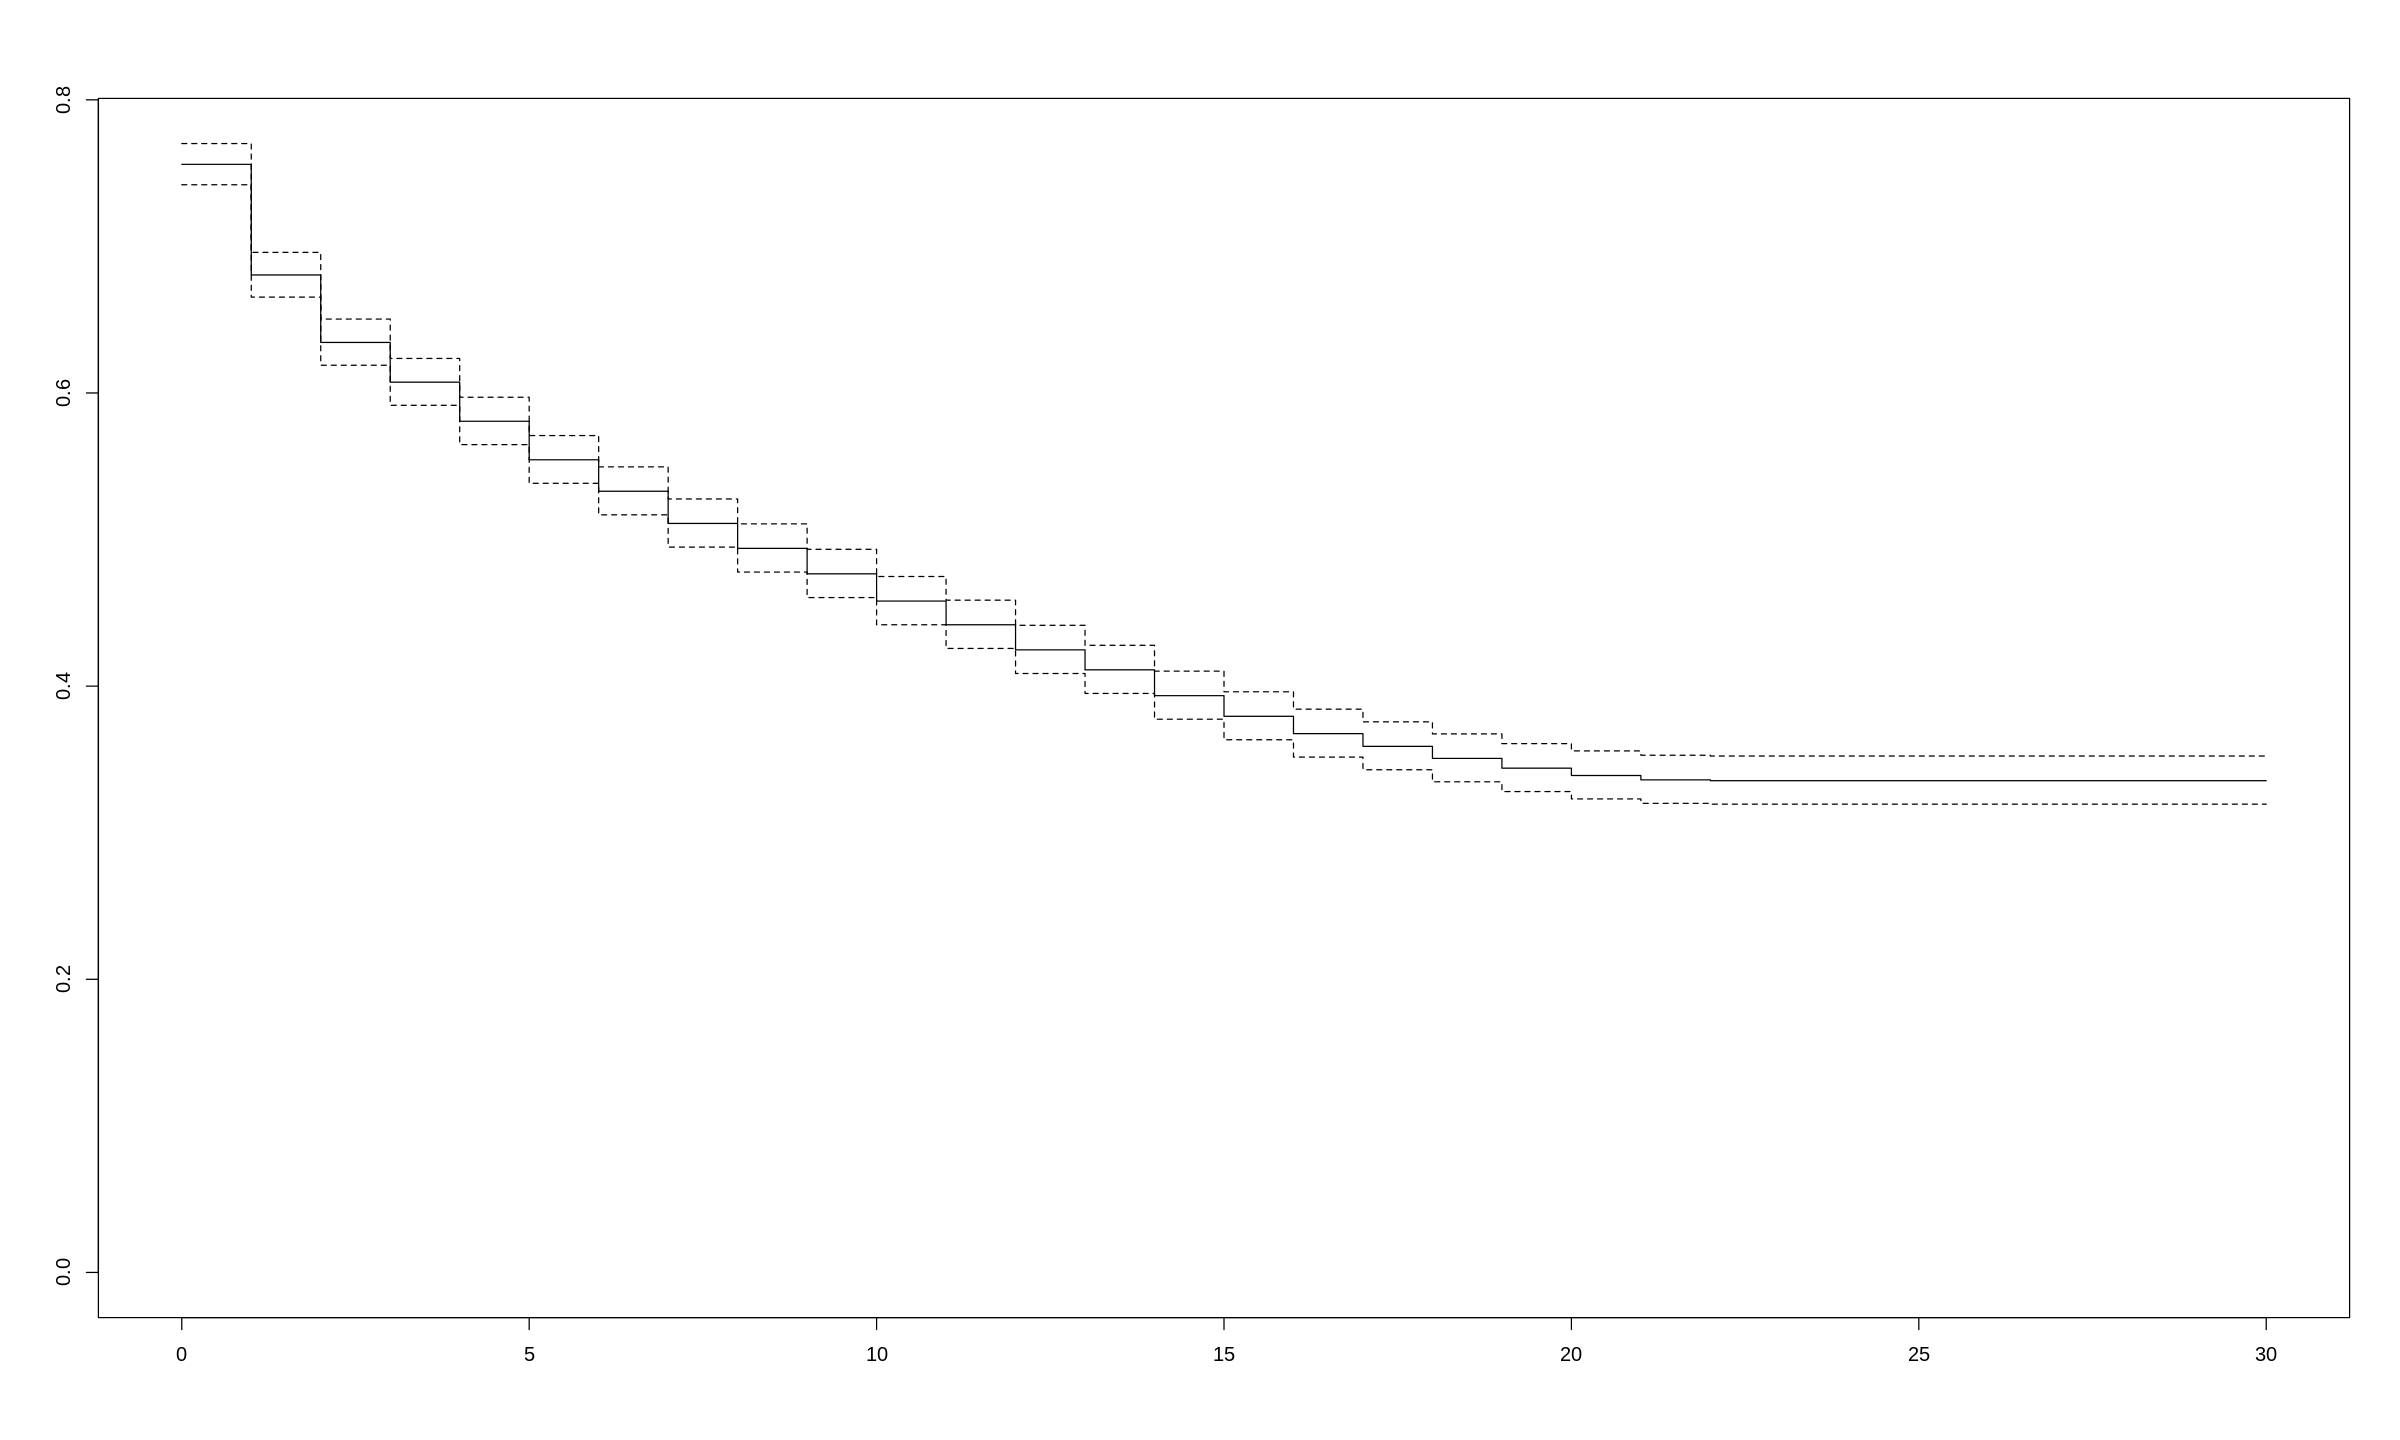

In [ ]:
# Actualizamos el tamaño del plot
options(repr.plot.width=20, repr.plot.height=12)
# Ploteamos la curva de supervivencia obtenida
sfit <- survfit(Surv(userData$userLifetime, userData$churned)~1, data=userData)
plot(sfit)

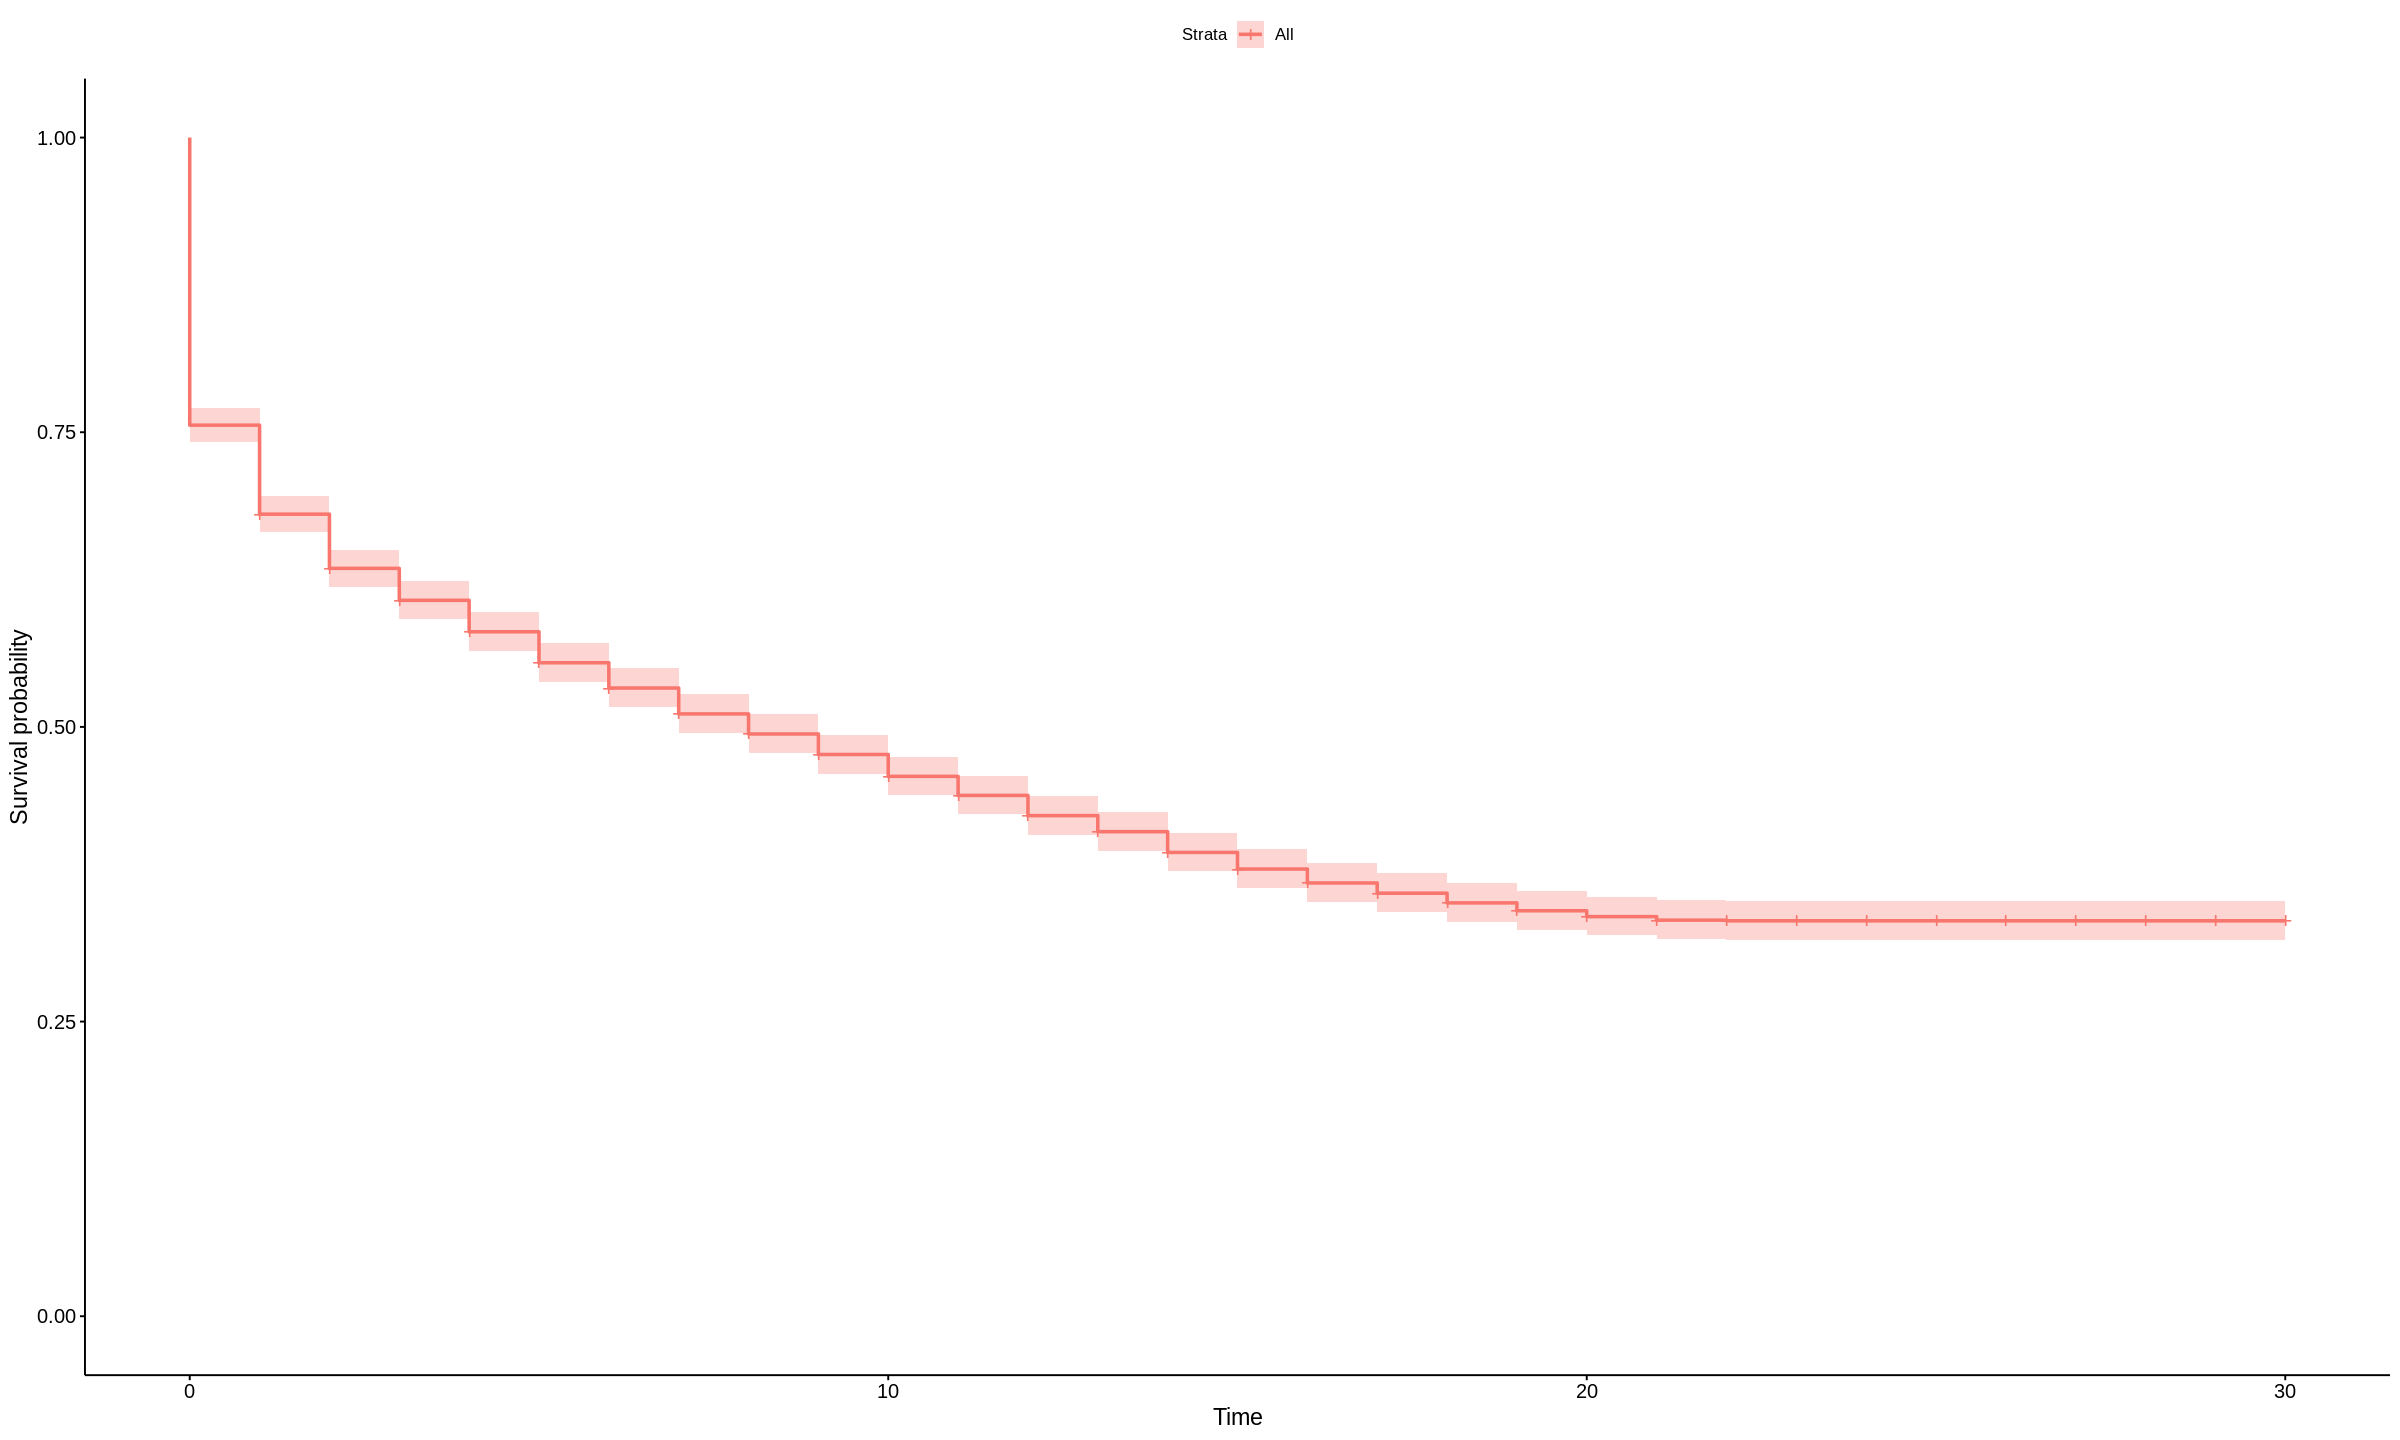

In [ ]:
# Make plots wider
options(repr.plot.width=20, repr.plot.height=12)
# La librería survminer nos ayuda a generar survival plots con formato, intervalos de confianza...
ggsurvplot(sfit)

En este caso hemos obtenido la curva general para todos los usuarios adquiridos durante el primer mes. Éste tipo de análisis nos permite comparar la calidad de los usuarios obtenidos por diferentes canales (Orgánico, de pago), en diferentes versiones de app, o en diferentes días.

En este caso y con la información que contamos haremos una comparación de cohortes por cada semana de adquisición de usuario.

userid,minDate,maxDate,latestDate,latestDateLag7Days,dateDiff,userLifetime,churned,cohortWeek
<chr>,<date>,<date>,<date>,<date>,<dbl>,<dbl>,<dbl>,<fct>
00090,2016-05-02,2016-05-03,2016-05-27,2016-05-20,24,1,1,2016-05-01
00092,2016-05-05,2016-05-08,2016-05-27,2016-05-20,19,3,1,2016-05-01
0010,2016-05-03,2016-05-16,2016-05-27,2016-05-20,11,13,1,2016-05-01
00160,2016-04-30,2016-05-03,2016-05-27,2016-05-20,24,3,1,2016-04-24
00167,2016-05-03,2016-05-17,2016-05-27,2016-05-20,10,14,1,2016-05-01
0019,2016-05-11,2016-05-11,2016-05-27,2016-05-20,16,0,1,2016-05-08
0023,2016-05-02,2016-05-02,2016-05-27,2016-05-20,25,0,1,2016-05-01
00255,2016-04-29,2016-05-27,2016-05-27,2016-05-20,0,28,0,2016-04-24
00303,2016-05-13,2016-05-26,2016-05-27,2016-05-20,1,13,0,2016-05-08


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


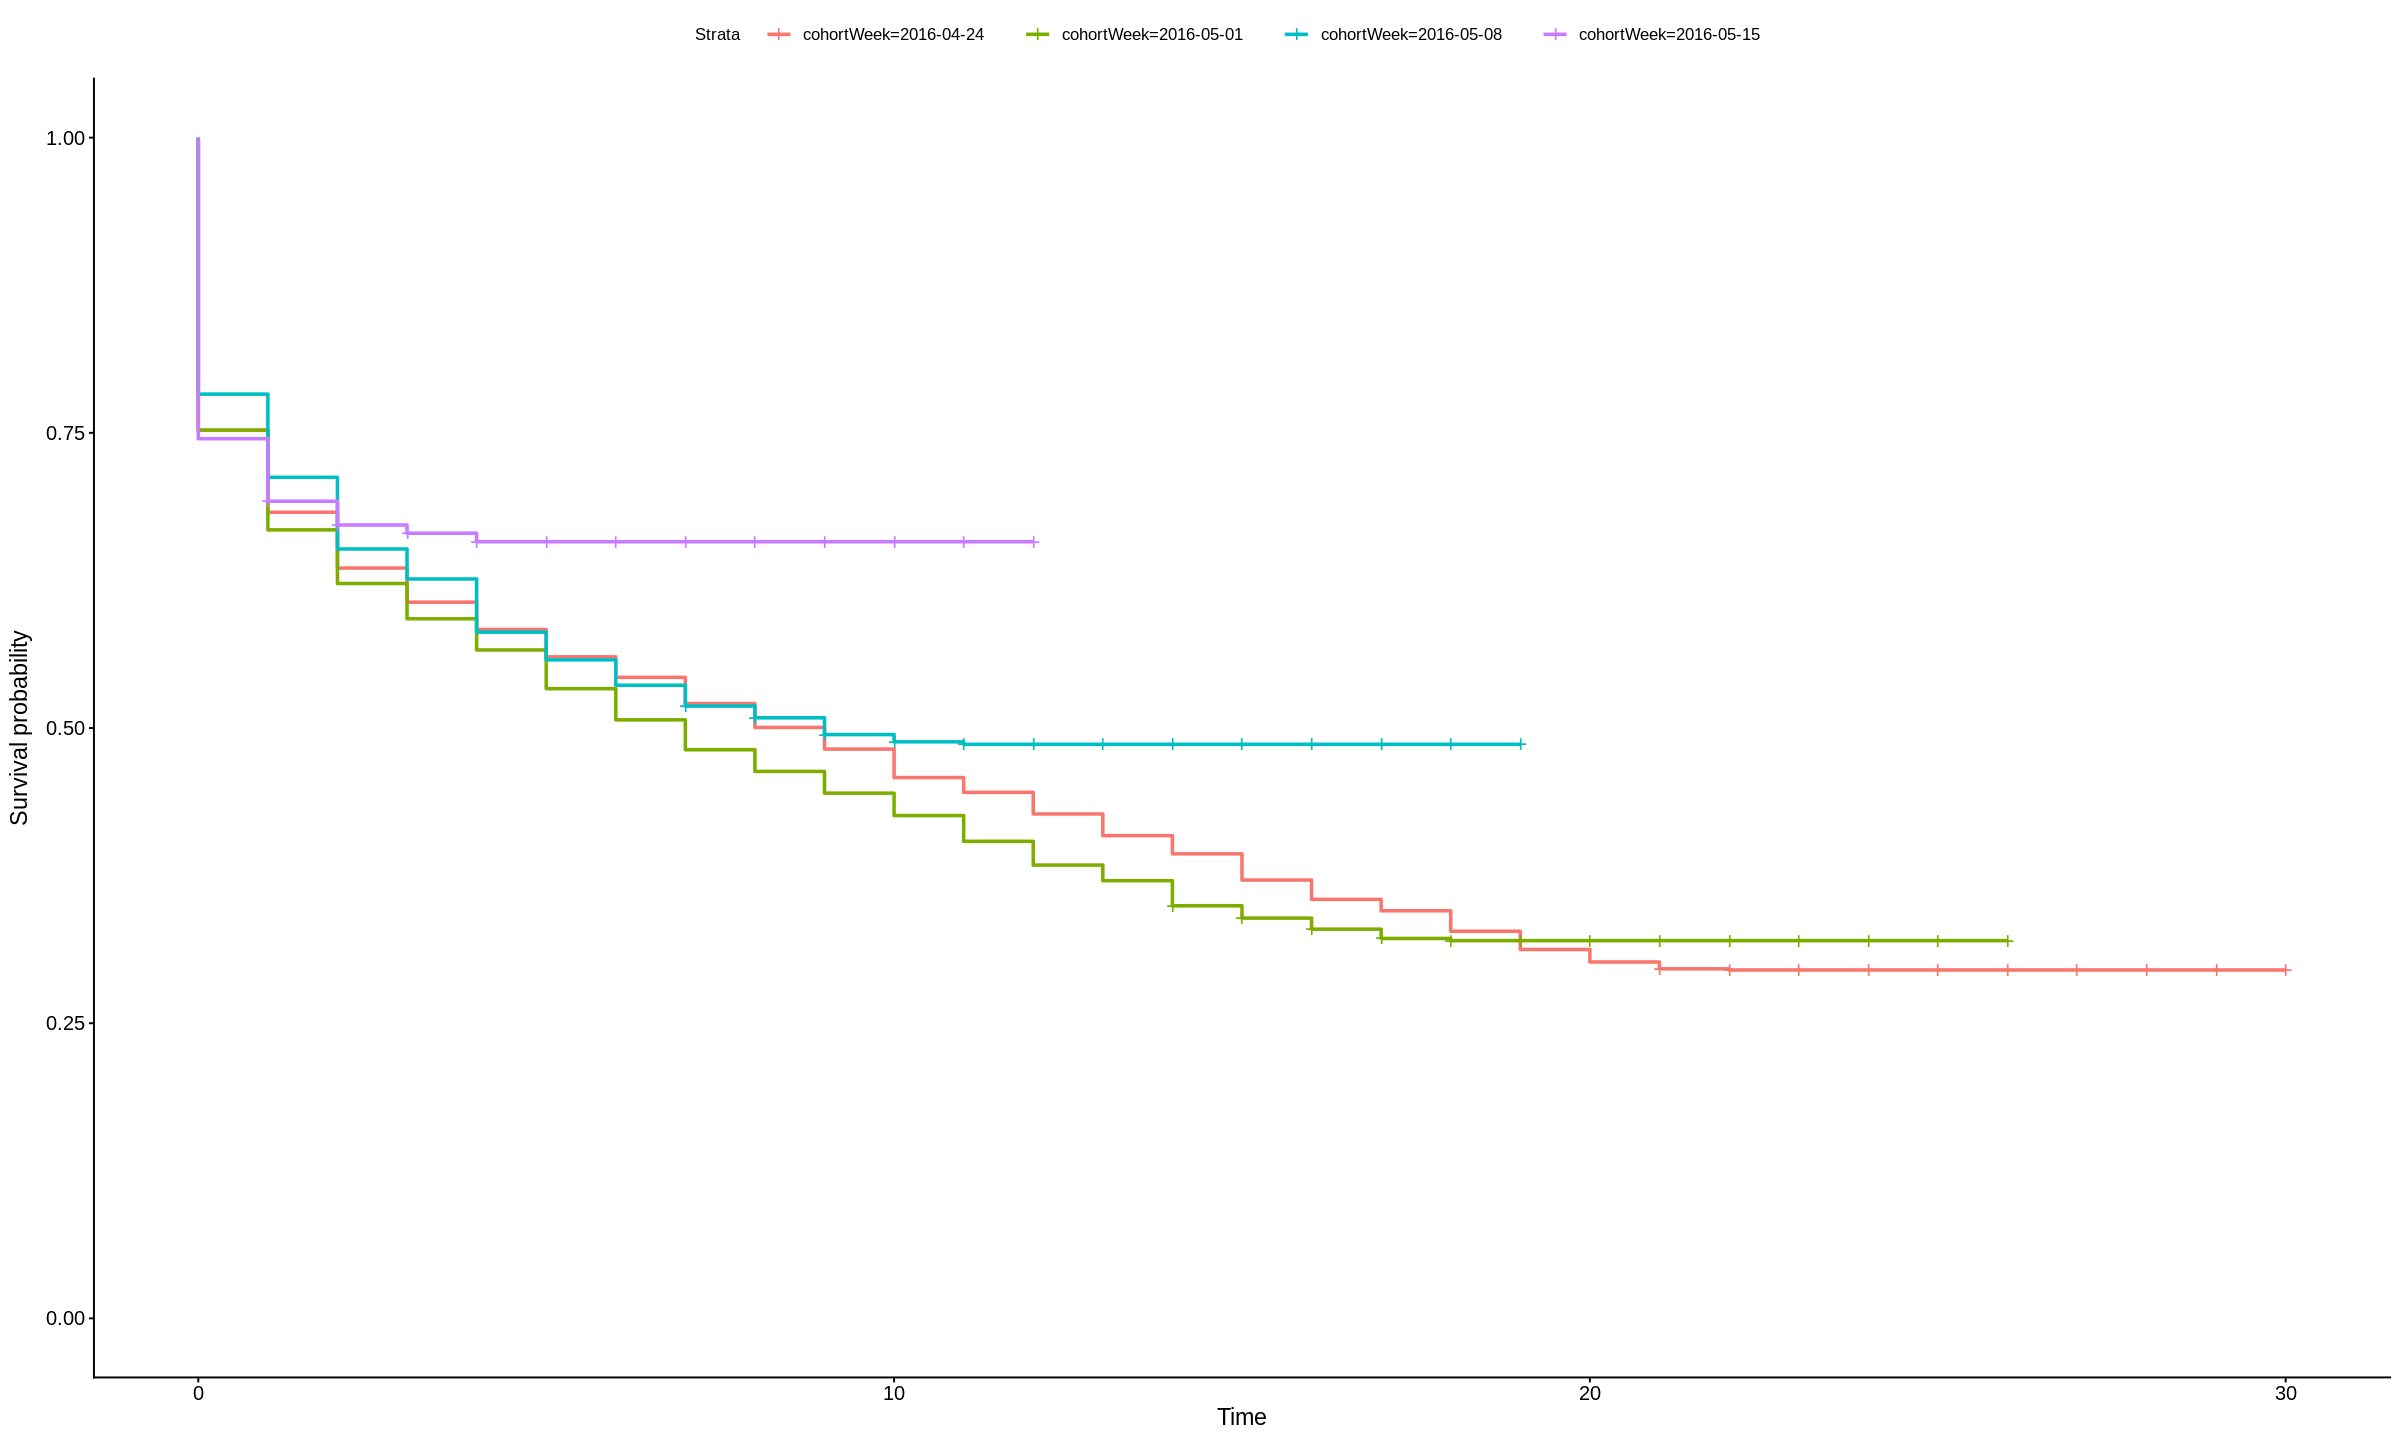

In [ ]:
# Make plots wider
options(repr.plot.width=20, repr.plot.height=12)
userData

sfitByWeek <- survfit(Surv(userLifetime, churned)~cohortWeek # cohortWeek indica la semana en la que el usuario fue adquirido
                      , data=userData)
ggsurvplot(sfitByWeek)

In [ ]:
R.version

               _                           
platform       x86_64-pc-linux-gnu         
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          5.0                         
year           2025                        
month          04                          
day            11                          
svn rev        88135                       
language       R                           
version.string R version 4.5.0 (2025-04-11)
nickname       How About a Twenty-Six      

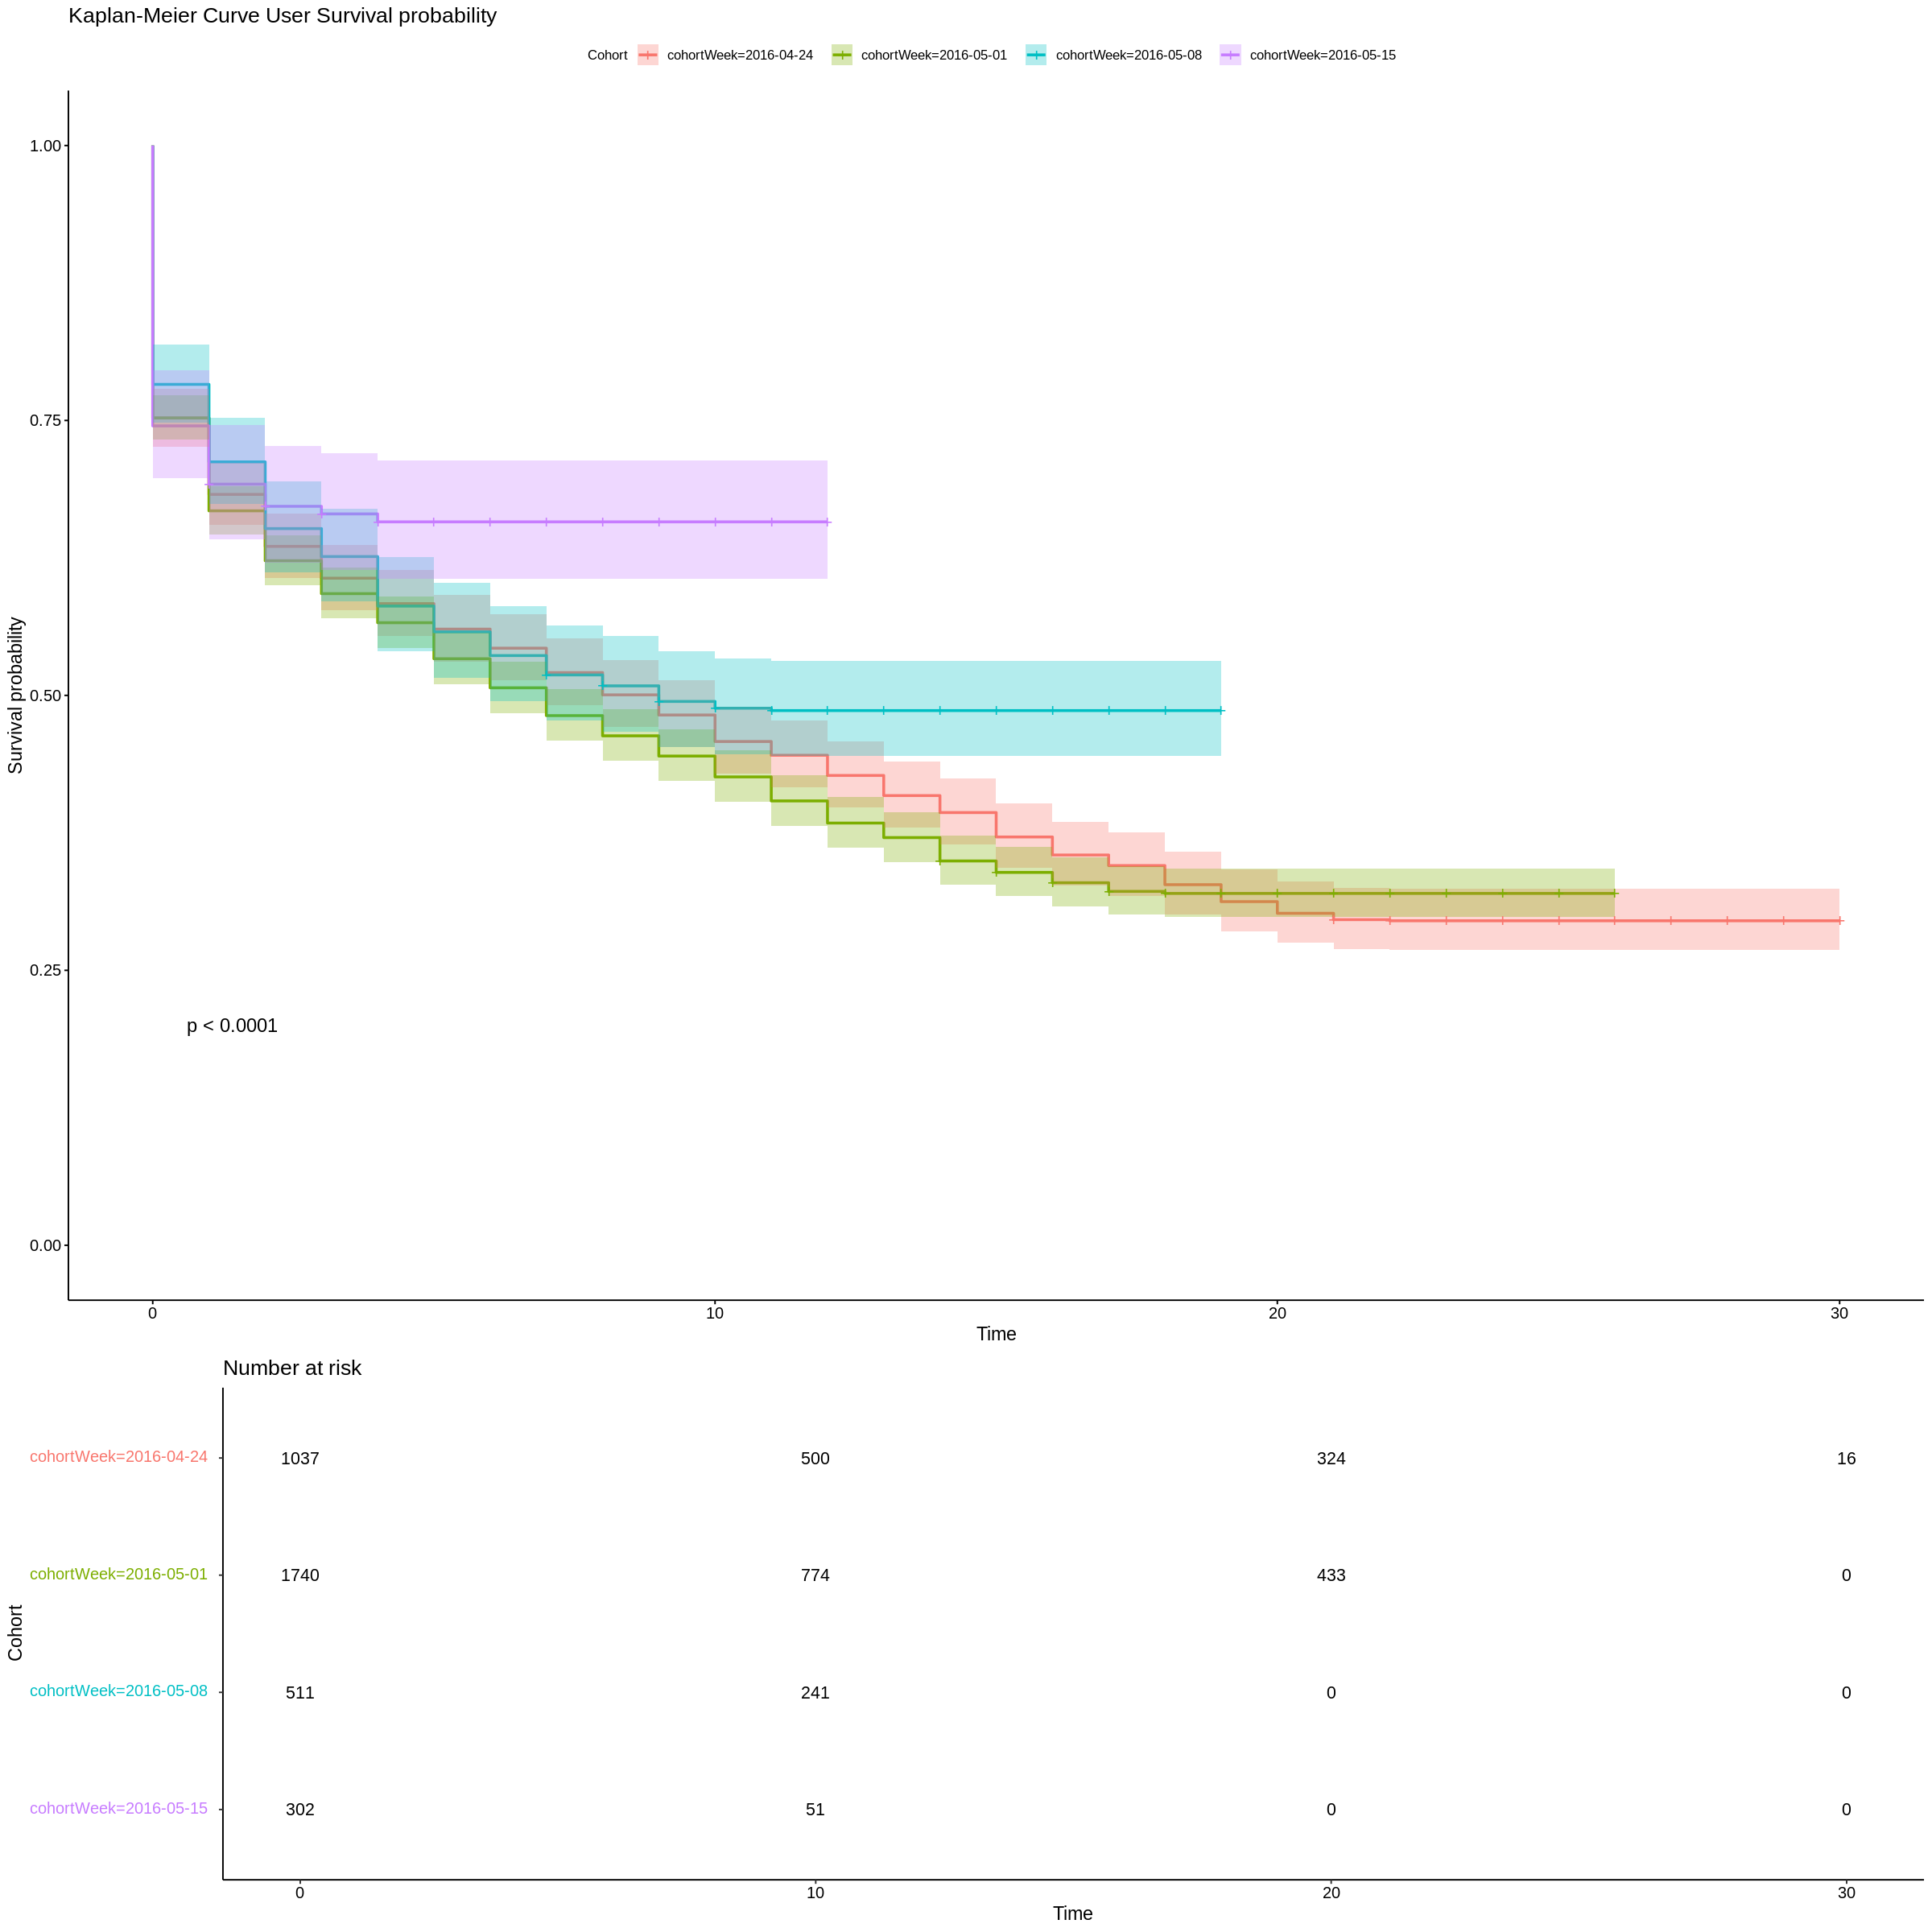

In [ ]:
# Make plots wider
options(repr.plot.width=20, repr.plot.height=20)
# Finalmente podemos aplicar una visión más completa sobre nuestro análisis para todos los cohortes
ggsurvplot(sfitByWeek
           , conf.int=TRUE
           , pval=TRUE
           , risk.table=TRUE
           #, legend.labs=c("1", "2", "3", "4")
           , legend.title="Cohort"
           , title="Kaplan-Meier Curve User Survival probability"
           , risk.table.height=.30)

In [ ]:
write.csv(gamelaunch, "gamelaunch.csv", row.names = FALSE)